In [ ]:
import chromatic_tda as chro
import matplotlib.pyplot as plt
import numpy as np
from gudhi import RipsComplex
from gudhi.representations import PersistenceImage

from persim import PersistenceImager
import persim.images_weights as weights

In [ ]:
def convert_into_diagram(diagram):
    """
    Converts kernel diagram dict → {dim: ndarray} and removes infinite deaths.
    """
    diagrams = {}
    for dim, pairs in diagram.items():
        filtered = [(float(b), float(d)) for (b, d) in pairs if np.isfinite(d)]
        diagrams[dim] = np.array(filtered)
    return diagrams

def convert_six_pack_to_diagram(six_pack):
    packs = {}

    for key, dgm in six_pack.items():
        pack = convert_into_diagram(dgm)
        packs[key] = pack

    return packs

In [ ]:
def compute_six_pack_diagrams(points, labels, max_edge = 10):
    chro_alpha = chro.ChromaticAlphaComplex(points, labels, max_alpha = max_edge)

    simplicial_complex = chro_alpha.get_simplicial_complex(
        sub_complex='0',
        full_complex='all',
        relative= None
    )

    six_pack = simplicial_complex.bars_six_pack()
    six_pack_dgms = convert_six_pack_to_diagram(six_pack)

    return six_pack_dgms

In [ ]:
A = np.random.rand(120, 2)*20
B = np.random.rand(80, 2)*20

In [ ]:
points = np.array(np.concatenate([A, B], axis = 0))
labels = np.array(np.concatenate([np.zeros(len(A)), np.ones(len(B))]))

six_pack_A_to_B = compute_six_pack_diagrams(points, labels, max_edge = 10)
six_pack_B_to_A = compute_six_pack_diagrams(points, 1-labels, max_edge = 10)

In [ ]:
def compute_PIs(barcodes, max_eps=10, px_res=0.1, sigma=0.05, normalization=False):
    keys = barcodes.keys()

    for key in keys:
        if len(barcodes[key]) == 0:
            barcodes[key] = np.zeros((0, 2))

    vector = {}

    # =========================================================================
    # H0 Persistence Image
    # 논문: birth_range=(0, 1), pers_range=(0, max_eps), skew=False
    # =========================================================================
    pers_imager_h0 = PersistenceImager()
    pers_imager_h0.pixel_size = px_res
    pers_imager_h0.birth_range = (0, 0.01)
    pers_imager_h0.pers_range = (0, max_eps)
    pers_imager_h0.weight = weights.persistence
    pers_imager_h0.weight_params = {'n': 1}
    pers_imager_h0.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}

    bars_h0 = np.array(barcodes[0])
    if len(bars_h0) > 0:
        # H0는 skew=False (이미 birth-persistence 형태로 간주)
        img_h0 = pers_imager_h0.transform(bars_h0, skew=True)
    else:
        img_h0 = np.zeros((int(1/px_res), int(max_eps/px_res)))

    # 논문: np.mean(img, axis=0) - birth 축을 따라 평균
    img0_1d = np.mean(img_h0, axis=0)

    # =========================================================================
    # H1 Persistence Image
    # 논문: birth_range=(0, max_eps), pers_range=(0, max_eps/2), skew=True
    # =========================================================================
    pers_imager_h1 = PersistenceImager()
    pers_imager_h1.pixel_size = px_res
    pers_imager_h1.birth_range = (0, max_eps)
    pers_imager_h1.pers_range = (0, max_eps / 2)
    pers_imager_h1.weight = weights.persistence
    pers_imager_h1.weight_params = {'n': 1}
    pers_imager_h1.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}

    bars_h1 = np.array(barcodes[1])
    if len(bars_h1) > 0:
        # H1은 skew=True ((birth, death) → (birth, persistence) 변환)
        img_h1 = pers_imager_h1.transform(bars_h1, skew=True)
    else:
        img_h1 = np.zeros((int(max_eps/px_res), int((max_eps/2)/px_res)))

    # =========================================================================
    # Normalization & Output
    # =========================================================================
    if normalization:
        if np.max(img0_1d) > 0:
            vector[0] = img0_1d / np.max(img0_1d)
        else:
            vector[0] = img0_1d

        if np.max(img_h1) > 0:
            vector[1] = img_h1.flatten() / np.max(img_h1)
        else:
            vector[1] = img_h1.flatten()
    else:
        vector[0] = img0_1d
        vector[1] = img_h1.flatten()

    return vector

def visualize_PIs(PIs, max_eps=10, px_res=0.1):
    import matplotlib.pyplot as plt

    # H0: shape (100,) - 1D image
    # 논문에서 mean(axis=0)으로 1D가 되었으므로 그대로 plot
    h0_img = PIs[0]
    h0_length = int(max_eps / px_res)  # 100

    # H1: shape (5000,) → reshape to (100, 50)
    h1_birth_bins = int(max_eps / px_res)  # 100
    h1_pers_bins = int((max_eps / 2) / px_res)  # 50
    h1_img = PIs[1].reshape((h1_birth_bins, h1_pers_bins))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # H0 (1D plot)
    axes[0].plot(h0_img, 'b-', linewidth=1.5)
    axes[0].fill_between(range(len(h0_img)), h0_img, alpha=0.3)
    axes[0].set_title(f'H0 Persistence Image (1D)\nLength: {h0_length}')
    axes[0].set_xlabel('Persistence (Bin Index)')
    axes[0].set_ylabel('Intensity')
    axes[0].set_xlim([0, h0_length])
    axes[0].grid(True, alpha=0.3)

    # H1 (2D image)
    im = axes[1].imshow(h1_img.T, cmap='hot', origin='lower', aspect='auto')
    axes[1].set_title(f'H1 Persistence Image (2D)\nResolution: ({h1_birth_bins}, {h1_pers_bins})')
    axes[1].set_xlabel('Birth (Bin Index)')
    axes[1].set_ylabel('Persistence (Bin Index)')
    plt.colorbar(im, ax=axes[1], label='Intensity')

    plt.tight_layout()
    plt.show()

In [ ]:
PI_six_pack_A_to_B = {}
PI_six_pack_B_to_A = {}

for key in six_pack_A_to_B.keys():
        PI = compute_PIs(six_pack_A_to_B[key], normalization = False)
        PI_six_pack_A_to_B[key] = PI


for key in six_pack_B_to_A.keys():
        PI = compute_PIs(six_pack_B_to_A[key], normalization = False)
        PI_six_pack_B_to_A[key] = PI

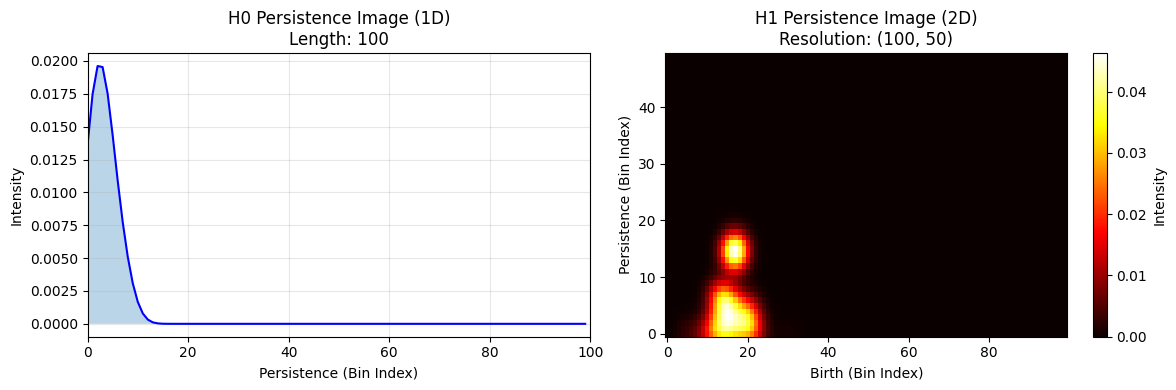

In [ ]:
visualize_PIs(PI_six_pack_B_to_A['kernel'])

In [ ]:
print(six_pack_A_to_B)

{'kernel': {0: array([[0.20195282, 0.21956503],
       [0.24747699, 0.45669782],
       [0.25679713, 0.3940067 ],
       [0.30489718, 0.34230362],
       [0.3129684 , 0.5587159 ],
       [0.36333581, 0.78260456],
       [0.367635  , 0.73974176],
       [0.4341817 , 0.72873698],
       [0.44639143, 0.98365526],
       [0.45092   , 0.76297737],
       [0.46605926, 0.7339955 ],
       [0.50902853, 0.81676443],
       [0.51291746, 0.57146542],
       [0.51865404, 0.55317914],
       [0.53026419, 0.53427817],
       [0.53220333, 0.96850255],
       [0.5385183 , 0.82773401],
       [0.55015545, 0.64161592],
       [0.5521753 , 1.12619627],
       [0.55910822, 0.78689534],
       [0.58699753, 1.06851194],
       [0.58916211, 0.64790449],
       [0.59375606, 0.97430573],
       [0.59671773, 1.06936727],
       [0.59715925, 0.81363073],
       [0.61324497, 0.97315823],
       [0.62128813, 0.94457073],
       [0.62711184, 0.81990077],
       [0.63577365, 0.83349127],
       [0.64192029, 1.097773